In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torchvision import transforms
import random
import os
from torch.utils.data import DataLoader, random_split
import json
from pathlib import Path

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.10.0+cpu


In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])
train_full = torchvision.datasets.EMNIST(
    root="./data",split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data",split="balanced", train=False, download=True, transform=transform
)


class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100.0%


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [26]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


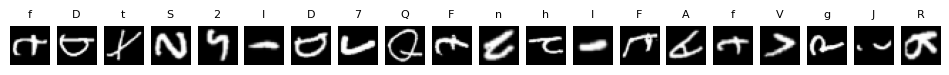

In [28]:

def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=20)

In [4]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256,512,128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [40]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()    

In [34]:
# обновление весов
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

# подсчёт метрик
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [35]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [44]:
def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [35]:
def plot_and_save_loss_history(path,history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(path, dpi=100,bbox_inches='tight')
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [47]:
baseline = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

epoch 01/20 | train loss=1.1102, acc=0.6579 | val loss=0.7361, acc=0.7628
epoch 02/20 | train loss=0.6234, acc=0.7918 | val loss=0.5811, acc=0.8066
epoch 03/20 | train loss=0.5258, acc=0.8191 | val loss=0.5481, acc=0.8164
epoch 04/20 | train loss=0.4677, acc=0.8372 | val loss=0.5299, acc=0.8204
epoch 05/20 | train loss=0.4304, acc=0.8459 | val loss=0.5500, acc=0.8235
epoch 06/20 | train loss=0.4001, acc=0.8559 | val loss=0.5343, acc=0.8271
epoch 07/20 | train loss=0.3773, acc=0.8624 | val loss=0.5024, acc=0.8363
epoch 08/20 | train loss=0.3556, acc=0.8681 | val loss=0.5075, acc=0.8403
epoch 09/20 | train loss=0.3366, acc=0.8742 | val loss=0.5344, acc=0.8305
epoch 10/20 | train loss=0.3262, acc=0.8766 | val loss=0.5134, acc=0.8396
epoch 11/20 | train loss=0.3098, acc=0.8823 | val loss=0.5321, acc=0.8402
epoch 12/20 | train loss=0.3027, acc=0.8845 | val loss=0.5138, acc=0.8489
epoch 13/20 | train loss=0.2919, acc=0.8881 | val loss=0.5567, acc=0.8382
epoch 14/20 | train loss=0.2820, acc=0

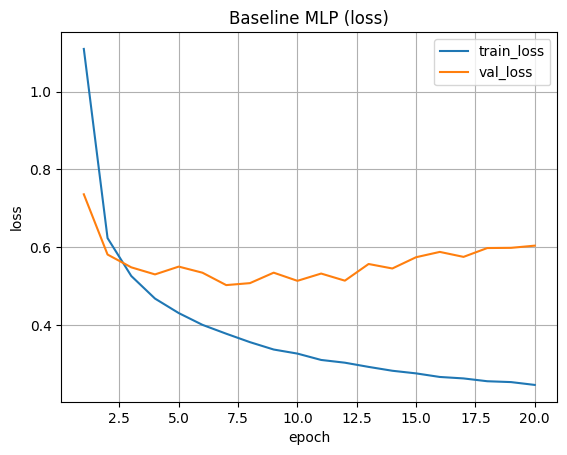

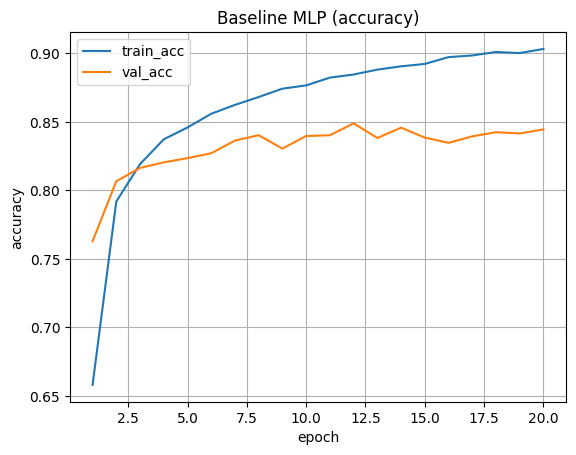

In [51]:
plot_history(history_baseline, title="Baseline MLP")

In [48]:
dropout_model = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)


epoch 01/20 | train loss=1.6277, acc=0.5215 | val loss=0.8226, acc=0.7309
epoch 02/20 | train loss=1.0020, acc=0.6931 | val loss=0.6935, acc=0.7739
epoch 03/20 | train loss=0.8865, acc=0.7249 | val loss=0.6378, acc=0.7940
epoch 04/20 | train loss=0.8283, acc=0.7410 | val loss=0.6354, acc=0.7896
epoch 05/20 | train loss=0.7939, acc=0.7532 | val loss=0.5737, acc=0.8133
epoch 06/20 | train loss=0.7655, acc=0.7594 | val loss=0.5672, acc=0.8177
epoch 07/20 | train loss=0.7490, acc=0.7641 | val loss=0.5627, acc=0.8162
epoch 08/20 | train loss=0.7338, acc=0.7703 | val loss=0.5516, acc=0.8183
epoch 09/20 | train loss=0.7184, acc=0.7732 | val loss=0.5578, acc=0.8167
epoch 10/20 | train loss=0.7097, acc=0.7764 | val loss=0.5338, acc=0.8259
epoch 11/20 | train loss=0.6953, acc=0.7790 | val loss=0.5498, acc=0.8219
epoch 12/20 | train loss=0.6966, acc=0.7815 | val loss=0.5234, acc=0.8292
epoch 13/20 | train loss=0.6895, acc=0.7821 | val loss=0.5195, acc=0.8293
epoch 14/20 | train loss=0.6723, acc=0

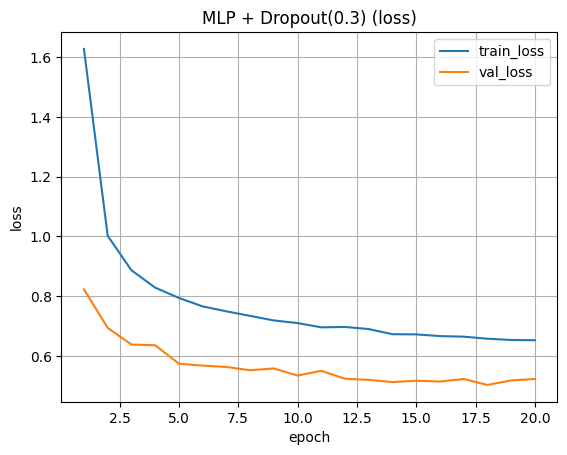

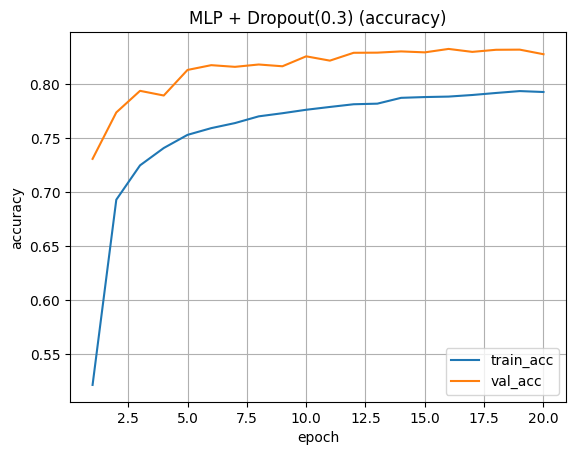

In [52]:
plot_history(history_dropout, title="MLP + Dropout(0.3)")

In [49]:
bn_model = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

epoch 01/20 | train loss=0.8581, acc=0.7427 | val loss=0.5582, acc=0.8153
epoch 02/20 | train loss=0.5179, acc=0.8231 | val loss=0.4743, acc=0.8388
epoch 03/20 | train loss=0.4403, acc=0.8446 | val loss=0.4392, acc=0.8484
epoch 04/20 | train loss=0.3944, acc=0.8568 | val loss=0.4220, acc=0.8522
epoch 05/20 | train loss=0.3569, acc=0.8685 | val loss=0.4188, acc=0.8593
epoch 06/20 | train loss=0.3298, acc=0.8751 | val loss=0.4201, acc=0.8575
epoch 07/20 | train loss=0.3045, acc=0.8828 | val loss=0.4113, acc=0.8605
epoch 08/20 | train loss=0.2839, acc=0.8905 | val loss=0.4269, acc=0.8599
epoch 09/20 | train loss=0.2695, acc=0.8941 | val loss=0.4146, acc=0.8632
epoch 10/20 | train loss=0.2514, acc=0.9006 | val loss=0.4222, acc=0.8619
epoch 11/20 | train loss=0.2398, acc=0.9035 | val loss=0.4253, acc=0.8603
epoch 12/20 | train loss=0.2257, acc=0.9076 | val loss=0.4355, acc=0.8621
epoch 13/20 | train loss=0.2156, acc=0.9125 | val loss=0.4369, acc=0.8629
epoch 14/20 | train loss=0.2039, acc=0

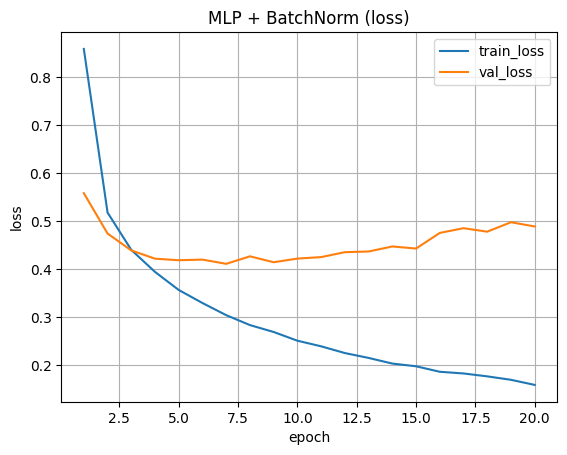

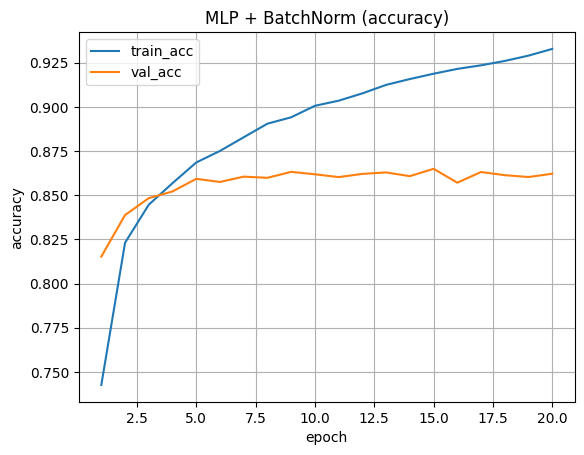

In [53]:
plot_history(history_bn, title="MLP + BatchNorm")

In [57]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [66]:
if max(history_bn["val_acc"]) > max(history_dropout["val_acc"]):
    print("лучший из (E2/E3) - E3")
else:
    print("лучший из (E2/E3) - E2")

лучший из (E2/E3) - E3


In [67]:
combo_model_new = MLP(hidden_dims=(1024,512,256,128), dropout_p=0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model_new.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo_new = fit(
    combo_model_new, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

epoch 01/50 | train loss=0.8577, acc=0.7427 | val loss=0.5387, acc=0.8192
epoch 02/50 | train loss=0.5176, acc=0.8225 | val loss=0.4665, acc=0.8415
epoch 03/50 | train loss=0.4425, acc=0.8433 | val loss=0.4413, acc=0.8488
epoch 04/50 | train loss=0.3925, acc=0.8572 | val loss=0.4313, acc=0.8502
epoch 05/50 | train loss=0.3607, acc=0.8673 | val loss=0.4322, acc=0.8475
epoch 06/50 | train loss=0.3290, acc=0.8760 | val loss=0.4176, acc=0.8567
epoch 07/50 | train loss=0.3063, acc=0.8830 | val loss=0.4245, acc=0.8565
epoch 08/50 | train loss=0.2861, acc=0.8894 | val loss=0.4243, acc=0.8565
epoch 09/50 | train loss=0.2677, acc=0.8950 | val loss=0.4273, acc=0.8598
epoch 10/50 | train loss=0.2528, acc=0.8988 | val loss=0.4174, acc=0.8650
epoch 11/50 | train loss=0.2370, acc=0.9056 | val loss=0.4276, acc=0.8644
epoch 12/50 | train loss=0.2261, acc=0.9088 | val loss=0.4381, acc=0.8601
epoch 13/50 | train loss=0.2165, acc=0.9115 | val loss=0.4552, acc=0.8595
epoch 14/50 | train loss=0.2054, acc=0

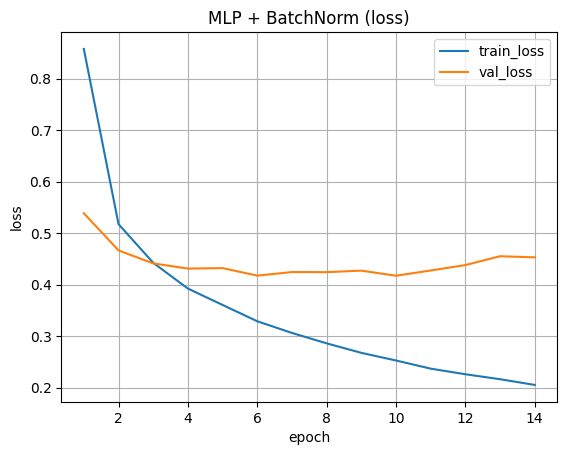

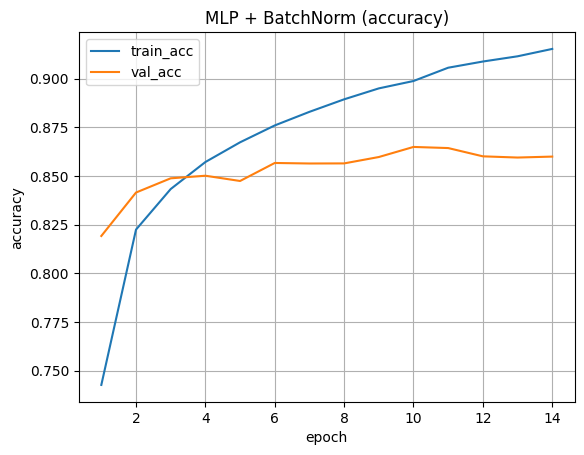

In [69]:
plot_history(history_combo_new, title="MLP + BatchNorm")

эксперемент не дал лучшего результата и практически ничем не отличается от E3, поэтому попробую изменить dropout_p на 0.3, как бы совместив эксперементы E2 и E3

In [16]:
combo_model = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

epoch 01/50 | train loss=1.2507, acc=0.6388 | val loss=0.6406, acc=0.7895
epoch 02/50 | train loss=0.7903, acc=0.7479 | val loss=0.5387, acc=0.8197
epoch 03/50 | train loss=0.6949, acc=0.7756 | val loss=0.4896, acc=0.8324
epoch 04/50 | train loss=0.6305, acc=0.7925 | val loss=0.4557, acc=0.8432
epoch 05/50 | train loss=0.5929, acc=0.8029 | val loss=0.4472, acc=0.8475
epoch 06/50 | train loss=0.5641, acc=0.8113 | val loss=0.4226, acc=0.8519
epoch 07/50 | train loss=0.5315, acc=0.8195 | val loss=0.4147, acc=0.8547
epoch 08/50 | train loss=0.5107, acc=0.8245 | val loss=0.4059, acc=0.8609
epoch 09/50 | train loss=0.4915, acc=0.8307 | val loss=0.4019, acc=0.8592
epoch 10/50 | train loss=0.4786, acc=0.8350 | val loss=0.3971, acc=0.8609
epoch 11/50 | train loss=0.4641, acc=0.8391 | val loss=0.3934, acc=0.8613
epoch 12/50 | train loss=0.4527, acc=0.8421 | val loss=0.3856, acc=0.8658
epoch 13/50 | train loss=0.4390, acc=0.8460 | val loss=0.3856, acc=0.8663
epoch 14/50 | train loss=0.4297, acc=0

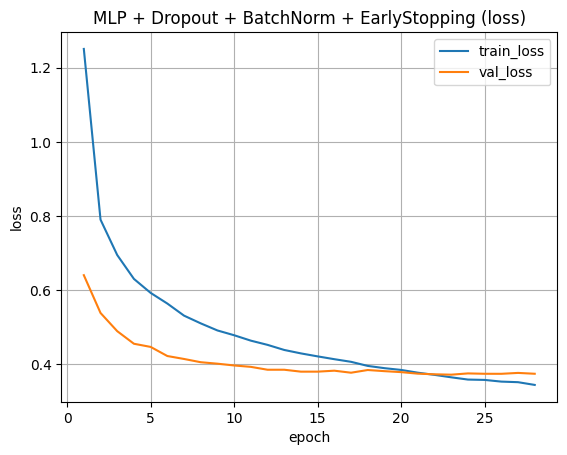

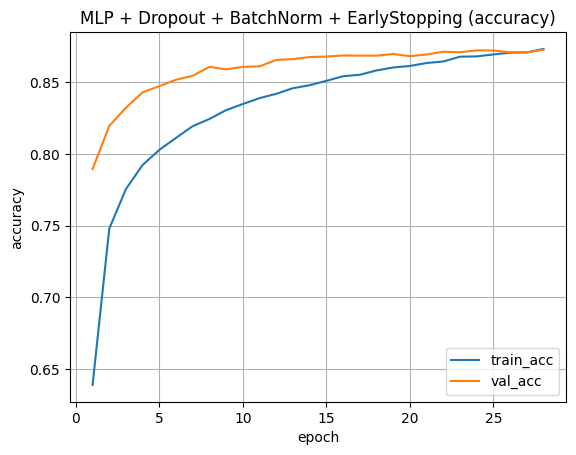

In [37]:
plot_and_save_loss_history("artifacts/figures/curves_best.png",history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")

действительно, результат сильно лучше и на графиках точно видно отсутствие переобучения

In [60]:
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Combo test: loss=0.3902, acc=0.8702


In [20]:
# сохранение лучшей модели (E4)

tmp_path = 'artifacts/best_model.pt'
torch.save(combo_model.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')

# Загрузка в новый экземпляр
model2 = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=True).to(device)
state = torch.load(tmp_path, map_location=device)
model2.load_state_dict(state)
model2.eval()

with torch.no_grad():
    out1 = combo_model(x_batch.to(device))
    out2 = model2(x_batch.to(device))
print('max |out1-out2|:', (out1 - out2).abs().max().item())

saved to artifacts/best_model.pt size: 6036213 bytes
max |out1-out2|: 0.0


In [27]:
# функция для сохранения файлов формата json
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

In [29]:
# конфиг лучшей модели
best_config = {
    "архитектура": {
        "input_dim": 28 * 28,
        "hidden_dims": [1024, 512, 256, 128],  
        "num_classes": 47,
        "activation": "relu",
    },
    "гиперпараметры": {
        "dropout_p": 0.3,
        "use_batchnorm": True,
        "learning_rate": 1e-3,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "use_EarlyStopping": {
            "patience": 4, 
            "min_delta": 0.0005,
        }
    },
    "seed": 42,  # убрал лишние скобки {}
    "датасет": "EMNIST"  # убрал лишние скобки {}
}

save_json(best_config, Path("artifacts/best_config.json"))

In [39]:
combo_model_LR_big = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_big = optim.Adam(combo_model_LR_big.parameters(), lr=1)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo_LR_big = fit(
    combo_model_LR_big, train_loader, val_loader,
    optimizer_big, criterion, device,
    epochs=8,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

epoch 01/8 | train loss=4.1644, acc=0.0215 | val loss=3.9789, acc=0.0211
epoch 02/8 | train loss=4.0498, acc=0.0209 | val loss=4.0293, acc=0.0226
epoch 03/8 | train loss=4.0345, acc=0.0212 | val loss=4.0759, acc=0.0228
epoch 04/8 | train loss=4.0429, acc=0.0207 | val loss=4.0383, acc=0.0213
epoch 05/8 | train loss=4.0340, acc=0.0215 | val loss=4.0497, acc=0.0211
epoch 06/8 | train loss=4.0357, acc=0.0214 | val loss=4.0516, acc=0.0213
EarlyStopping: остановка на эпохе 6. Лучший val_acc=0.0226


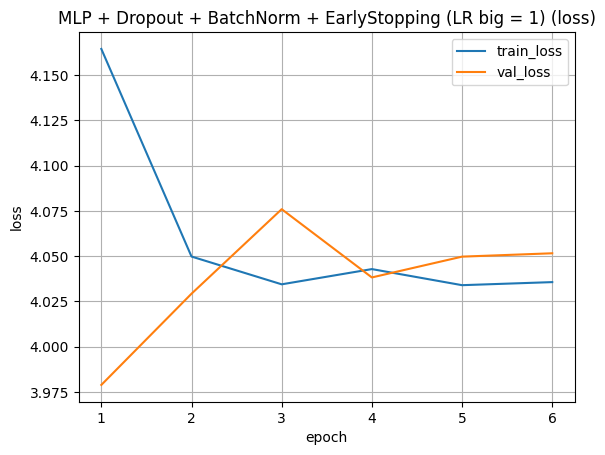

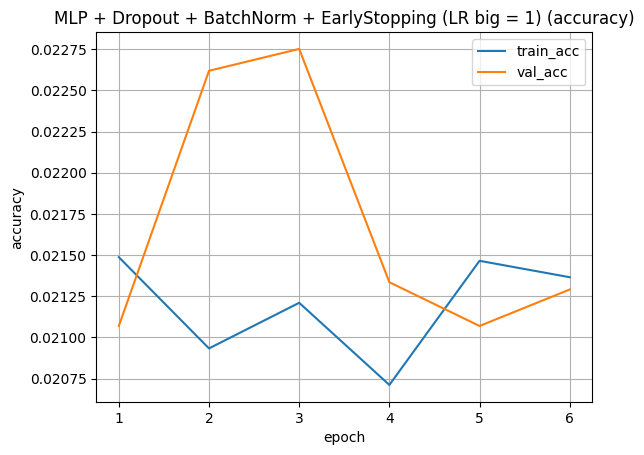

In [40]:
plot_history(history_combo_LR_big, title="MLP + Dropout + BatchNorm + EarlyStopping (LR big = 1)")

In [41]:
combo_model_LR_min = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_min = optim.Adam(combo_model_LR_min.parameters(), lr=1e-7)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo_min = fit(
    combo_model_LR_min, train_loader, val_loader,
    optimizer_min, criterion, device,
    epochs=8,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

epoch 01/8 | train loss=3.9613, acc=0.0199 | val loss=3.8779, acc=0.0153
epoch 02/8 | train loss=3.9547, acc=0.0208 | val loss=3.8698, acc=0.0166
epoch 03/8 | train loss=3.9491, acc=0.0210 | val loss=3.8612, acc=0.0188
epoch 04/8 | train loss=3.9397, acc=0.0232 | val loss=3.8536, acc=0.0208
epoch 05/8 | train loss=3.9312, acc=0.0229 | val loss=3.8460, acc=0.0228
epoch 06/8 | train loss=3.9240, acc=0.0237 | val loss=3.8374, acc=0.0237
epoch 07/8 | train loss=3.9168, acc=0.0249 | val loss=3.8289, acc=0.0276
epoch 08/8 | train loss=3.9098, acc=0.0260 | val loss=3.8214, acc=0.0293


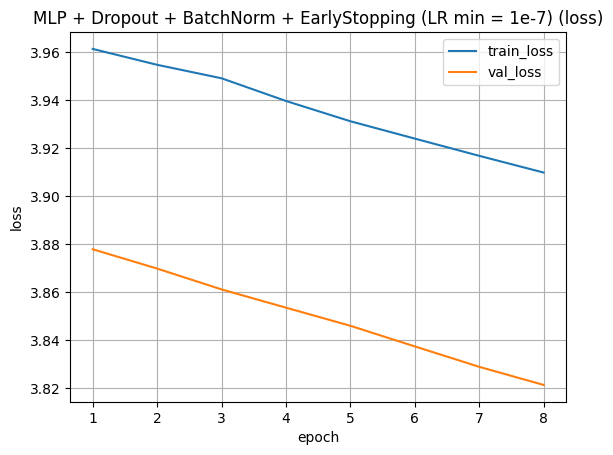

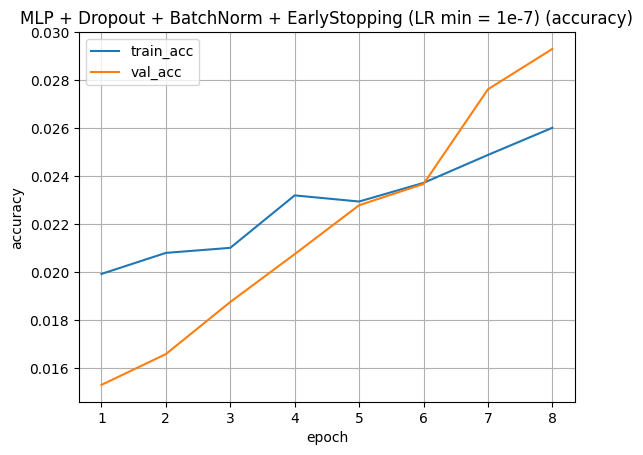

In [42]:
plot_history(history_combo_min, title="MLP + Dropout + BatchNorm + EarlyStopping (LR min = 1e-7)")

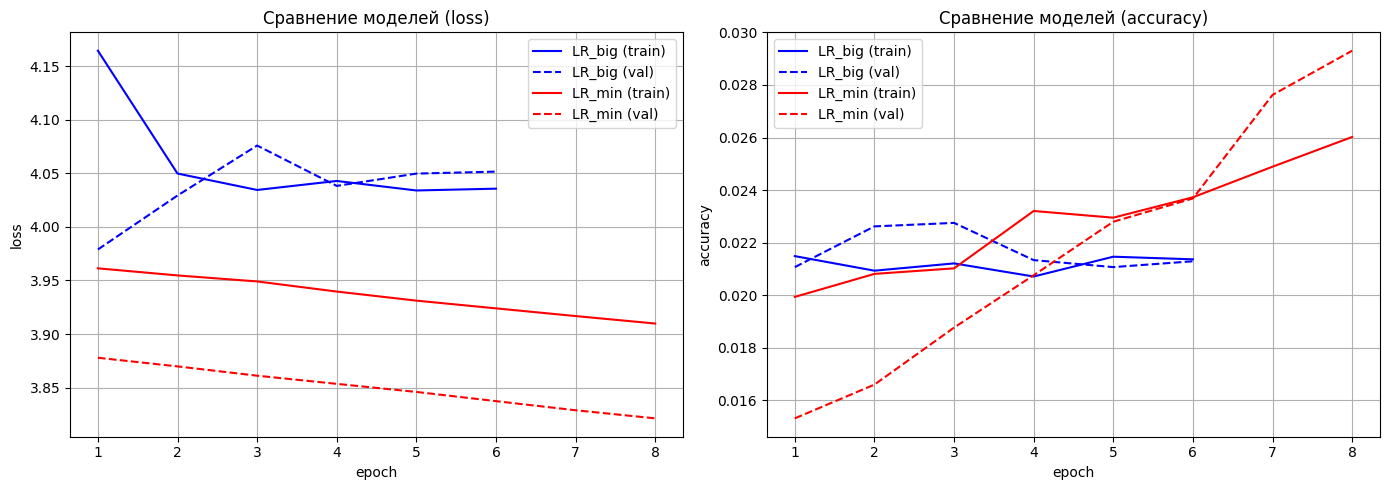

In [45]:
def plot_histories(path,history1: dict, history2: dict, 
                   label1: str = "Модель 1", 
                   label2: str = "Модель 2",
                   title: str = "") -> None:
    
    epochs1 = np.arange(1, len(history1["train_loss"]) + 1)
    epochs2 = np.arange(1, len(history2["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # График loss
    ax1.plot(epochs1, history1["train_loss"], 'b-', label=f"{label1} (train)")
    ax1.plot(epochs1, history1["val_loss"], 'b--', label=f"{label1} (val)")
    ax1.plot(epochs2, history2["train_loss"], 'r-', label=f"{label2} (train)")
    ax1.plot(epochs2, history2["val_loss"], 'r--', label=f"{label2} (val)")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title((title + " (loss)") if title else "loss")
    ax1.legend()
    ax1.grid(True)

    # График accuracy
    ax2.plot(epochs1, history1["train_acc"], 'b-', label=f"{label1} (train)")
    ax2.plot(epochs1, history1["val_acc"], 'b--', label=f"{label1} (val)")
    ax2.plot(epochs2, history2["train_acc"], 'r-', label=f"{label2} (train)")
    ax2.plot(epochs2, history2["val_acc"], 'r--', label=f"{label2} (val)")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title((title + " (accuracy)") if title else "accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(path, dpi=100,bbox_inches='tight')
    plt.show()
    
plot_histories("artifacts/figures/curves_lr_extremes.png",history_combo_LR_big, 
    history_combo_min,
    label1="LR_big",
    label2="LR_min",
    title="Сравнение моделей"
)

In [50]:
combo_model_sgb = MLP(hidden_dims=(1024,512,256,128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_sgd = optim.SGD(combo_model_sgb.parameters(),momentum=0.9, lr=1e-3,weight_decay=1e-4)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo_sgb = fit(
    combo_model_sgb, train_loader, val_loader,
    optimizer_sgd, criterion, device,
    epochs=15,  
    early_stopping=es,
    verbose=True
)

epoch 01/15 | train loss=2.5202, acc=0.3834 | val loss=1.3660, acc=0.6545
epoch 02/15 | train loss=1.4075, acc=0.6086 | val loss=0.8816, acc=0.7374
epoch 03/15 | train loss=1.1265, acc=0.6653 | val loss=0.7361, acc=0.7730
epoch 04/15 | train loss=0.9951, acc=0.6963 | val loss=0.6507, acc=0.7912
epoch 05/15 | train loss=0.9133, acc=0.7187 | val loss=0.6088, acc=0.8019
epoch 06/15 | train loss=0.8531, acc=0.7339 | val loss=0.5697, acc=0.8138
epoch 07/15 | train loss=0.8020, acc=0.7474 | val loss=0.5413, acc=0.8221
epoch 08/15 | train loss=0.7664, acc=0.7577 | val loss=0.5220, acc=0.8260
epoch 09/15 | train loss=0.7403, acc=0.7643 | val loss=0.5076, acc=0.8297
epoch 10/15 | train loss=0.7124, acc=0.7723 | val loss=0.4940, acc=0.8324
epoch 11/15 | train loss=0.6881, acc=0.7788 | val loss=0.4854, acc=0.8372
epoch 12/15 | train loss=0.6671, acc=0.7827 | val loss=0.4722, acc=0.8384
epoch 13/15 | train loss=0.6556, acc=0.7867 | val loss=0.4692, acc=0.8415
epoch 14/15 | train loss=0.6376, acc=0

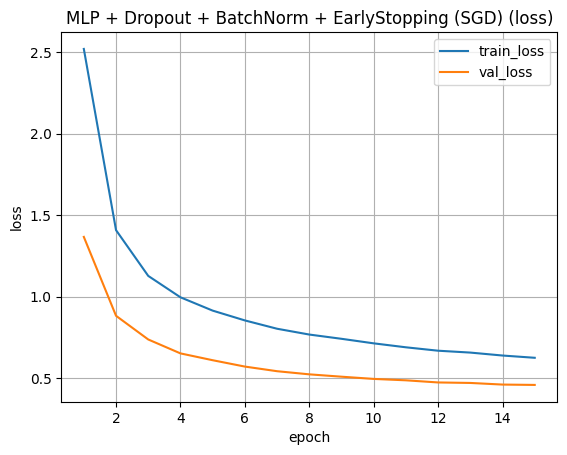

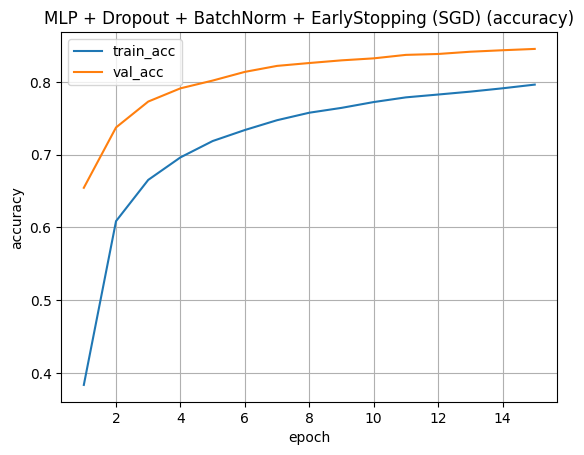

In [54]:
plot_history(history_combo_sgb, title="MLP + Dropout + BatchNorm + EarlyStopping (SGD)")

In [59]:
experiments_results = []

def add_experiment(experiment_id, dataset, model, history, optimizer, 
                   lr, momentum, weight_decay, dropout_p, use_batchnorm,hidden_dims="(1024,512,256,128)", activation="relu",seed=42):
    
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["train_loss"])
    
    model_summary = f"{hidden_dims}, {activation}, dropout={dropout_p}, batchnorm={use_batchnorm}"
    
    experiments_results.append({
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    })



add_experiment("E1", "EMNIST", baseline, history_baseline, 
               "Adam", 0.001, "", 0,dropout_p=0.0, use_batchnorm=False)

add_experiment("E2", "EMNIST", dropout_model, history_dropout, 
               "Adam", 0.001, "", 0,dropout_p=0.3, use_batchnorm=False)

add_experiment("E3", "EMNIST", bn_model, history_bn, 
               "Adam", 0.001, "", 0,dropout_p=0, use_batchnorm=True)

add_experiment("E4", "EMNIST", combo_model, history_combo, 
               "Adam", 0.001, "", 0,dropout_p=0.3, use_batchnorm=True)

add_experiment("O1", "EMNIST", combo_model_LR_big, history_combo_LR_big, 
               "Adam", 1, "", 0,dropout_p=0.3, use_batchnorm=True)

add_experiment("O2", "EMNIST", combo_model_LR_min, history_combo_min, 
               "Adam", 1e-7, "", 0,dropout_p=0.3, use_batchnorm=True)

add_experiment("O3", "EMNIST", combo_model_sgb, history_combo_sgb, 
               "SGD", 1e-3, 0.9, 1e-4,dropout_p=0.3, use_batchnorm=True)


df_results = pd.DataFrame(experiments_results)
df_results.to_csv("artifacts/runs.csv", index=False)
